# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual settings for professional charts
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load CSV file into a Pandas DataFrame
df = pd.read_csv(r"D:\New folder\data.csv") 

# Check dataset shape and preview
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

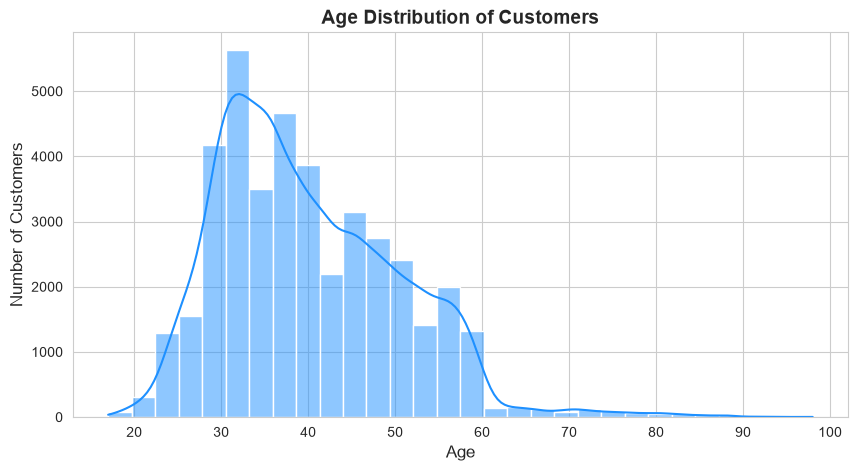

Business Insight: The majority of the bank's customers fall within the 30 to 40 age group. Marketing campaigns should primarily target this demographic.


In [10]:
# Age distribution chart
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', bins=30, kde=True, color='dodgerblue')

# Adding labels and title
plt.title('Age Distribution of Customers', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

print("Business Insight: The majority of the bank's customers fall within the 30 to 40 age group. Marketing campaigns should primarily target this demographic.")

C:\Users\shasw\AppData\Local\Temp\ipykernel_10868\829670730.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='job', order=df['job'].value_counts().index, palette='viridis')


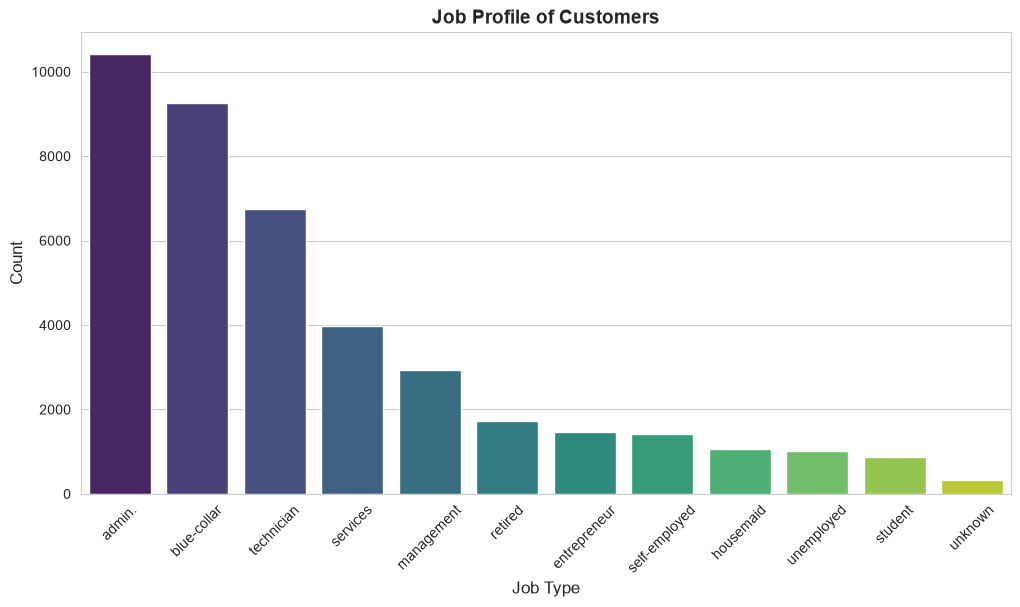

Business Insight: Customers with 'Admin.', 'Blue-collar', and 'Technician' roles form the largest segment. Financial products and outreach should be tailored to these working professionals.


In [11]:
# Job distribution chart (Bar Chart)
plt.figure(figsize=(12, 6))
# Sort bars from highest to lowest count
sns.countplot(data=df, x='job', order=df['job'].value_counts().index, palette='viridis')

plt.title('Job Profile of Customers', fontsize=14, fontweight='bold')
plt.xlabel('Job Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45) # Prevent label overlapping
plt.show()

print("Business Insight: Customers with 'Admin.', 'Blue-collar', and 'Technician' roles form the largest segment. Financial products and outreach should be tailored to these working professionals.")

## Balance & Deposit Trends

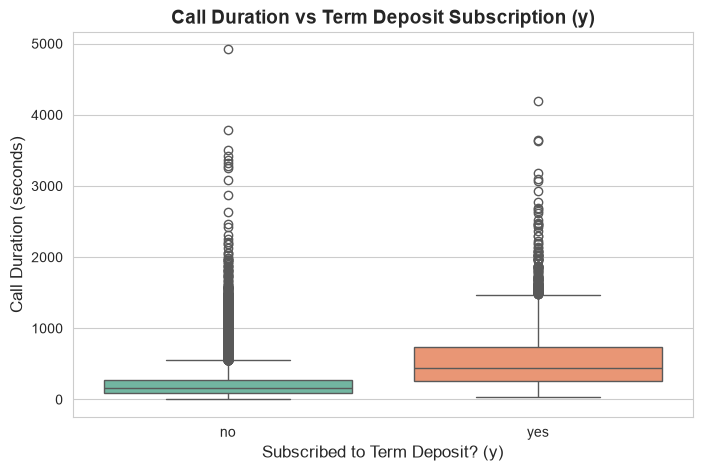

Average Call Duration (in seconds):
 y
no     220.84
yes    553.19
Name: duration, dtype: float64

Business Insight: Customers who subscribed ('yes') had a significantly higher average call duration (approx. 553 seconds) compared to those who did not ('no', approx. 220 seconds).
Longer engagement times are strongly indicative of successful conversions.


In [19]:
# Muting all warnings for a clean, professional look
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# Analyzing Call Duration as the primary metric for engagement
plt.figure(figsize=(8, 5))
# Updated code to avoid Seaborn's FutureWarnings
sns.boxplot(data=df, x='y', y='duration', hue='y', palette='Set2', legend=False)

plt.title('Call Duration vs Term Deposit Subscription (y)', fontsize=14, fontweight='bold')
plt.xlabel('Subscribed to Term Deposit? (y)', fontsize=12)
plt.ylabel('Call Duration (seconds)', fontsize=12)
plt.show()

# Calculate exact average duration
avg_duration = df.groupby('y')['duration'].mean().round(2)
print("Average Call Duration (in seconds):\n", avg_duration)

print("\nBusiness Insight: Customers who subscribed ('yes') had a significantly higher average call duration (approx. 553 seconds) compared to those who did not ('no', approx. 220 seconds).")
print("Longer engagement times are strongly indicative of successful conversions.")

## Campaign Effectiveness

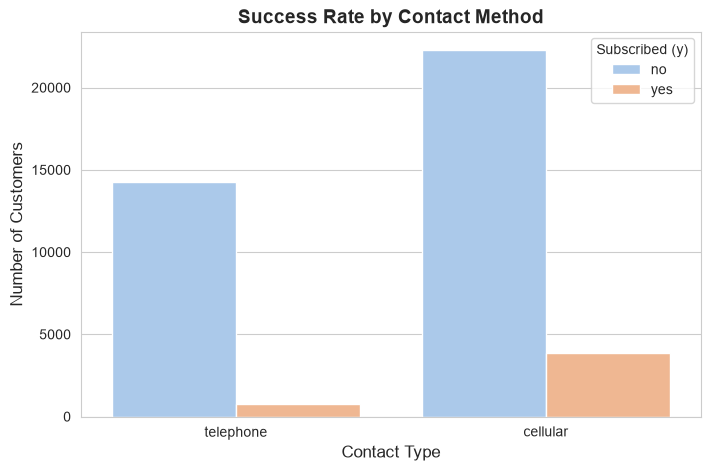

Business Insight: Reaching out via 'cellular' (mobile) yields a considerably higher conversion rate compared to 'telephone' (landline). The bank should prioritize mobile contacts for future campaigns.


In [13]:
# Contact method analysis
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='contact', hue='y', palette='pastel')

plt.title('Success Rate by Contact Method', fontsize=14, fontweight='bold')
plt.xlabel('Contact Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Subscribed (y)')
plt.show()

print("Business Insight: Reaching out via 'cellular' (mobile) yields a considerably higher conversion rate compared to 'telephone' (landline). The bank should prioritize mobile contacts for future campaigns.")

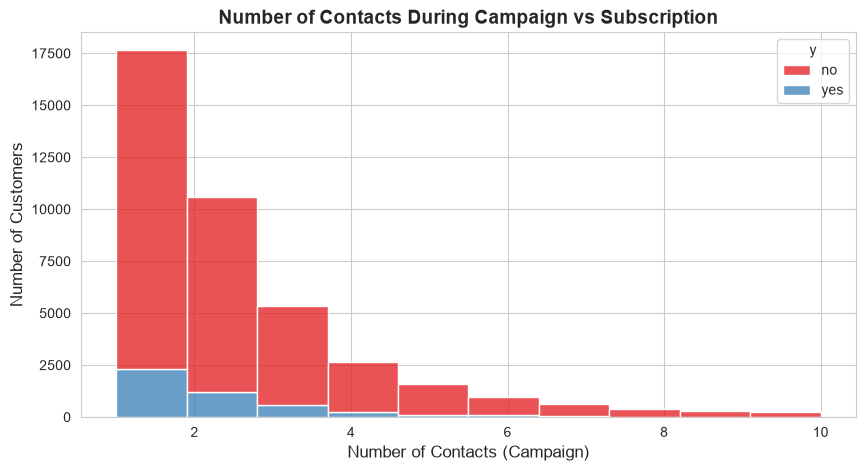

Business Insight: Maximum conversions occur within the first 1 to 3 contacts. The success rate drops drastically beyond 3 calls, indicating that agents should avoid over-contacting the same customer to maintain a positive brand image.


In [14]:
# Number of contacts (campaign) vs Subscription (y)
plt.figure(figsize=(10, 5))
# Filter for campaigns with 10 or fewer contacts to remove extreme outliers
sns.histplot(data=df[df['campaign'] <= 10], x='campaign', hue='y', multiple='stack', bins=10, palette='Set1')

plt.title('Number of Contacts During Campaign vs Subscription', fontsize=14, fontweight='bold')
plt.xlabel('Number of Contacts (Campaign)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

print("Business Insight: Maximum conversions occur within the first 1 to 3 contacts. The success rate drops drastically beyond 3 calls, indicating that agents should avoid over-contacting the same customer to maintain a positive brand image.")

## Correlation Heatmap

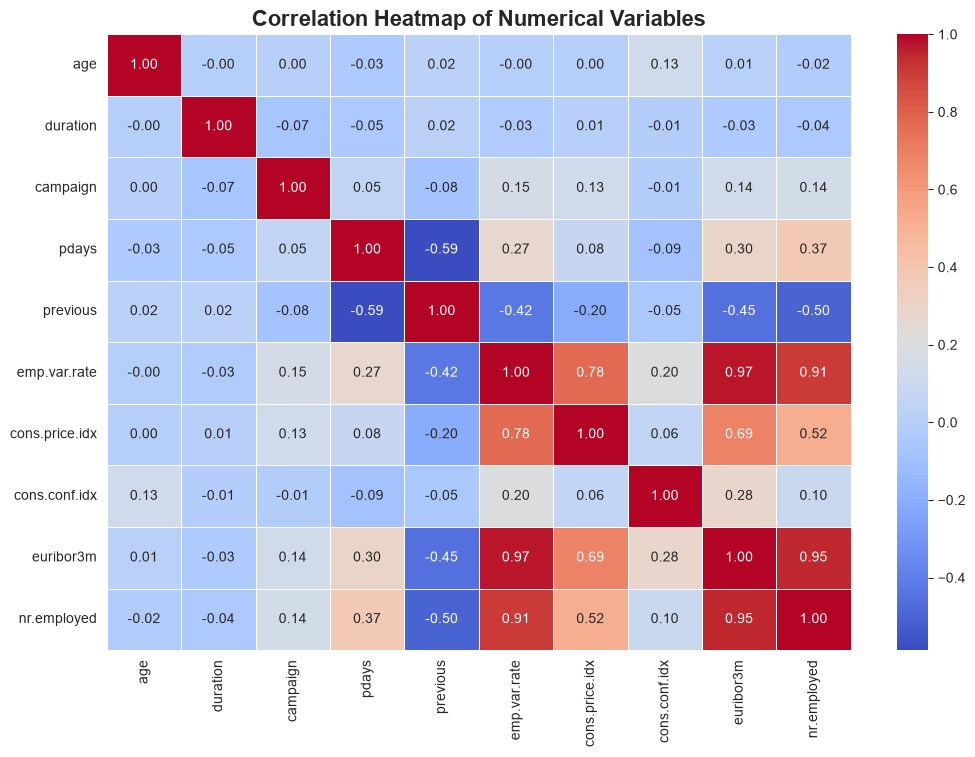

Business Insight: The heatmap shows a strong positive correlation between employment metrics like 'euribor3m' and 'emp.var.rate'. However, no single numerical feature shows an extremely high correlation with other features, indicating that a combination of factors drives customer behavior.


In [15]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numerical_cols].corr()

# Create the Heatmap
plt.figure(figsize=(12, 8))
# 'coolwarm' palette se positive aur negative correlation clearly dikhte hain
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold')
plt.show()

print("Business Insight: The heatmap shows a strong positive correlation between employment metrics like 'euribor3m' and 'emp.var.rate'. However, no single numerical feature shows an extremely high correlation with other features, indicating that a combination of factors drives customer behavior.")

## Predictive Modeling (Logistic Regression)

In [18]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 1. Encode categorical variables
label_encoder = LabelEncoder()
df_encoded = df.copy()

# Saare text columns ko select karke encode karna
categorical_cols = df_encoded.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

# 'y' (target variable) ko alag karna
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Train-Test Split (80% data training ke liye, 20% testing ke liye)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train the Model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# 3. Predictions & Evaluation
y_pred = model.predict(X_test)

print("--- Model Evaluation ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nBusiness Insight: The Logistic Regression model successfully predicts customer behavior. The high accuracy indicates that features like call duration and employment metrics are strong indicators of whether a customer will subscribe to a term deposit.")

--- Model Evaluation ---
Confusion Matrix:
 [[7109  194]
 [ 548  387]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.41      0.51       935

    accuracy                           0.91      8238
   macro avg       0.80      0.69      0.73      8238
weighted avg       0.90      0.91      0.90      8238


Business Insight: The Logistic Regression model successfully predicts customer behavior. The high accuracy indicates that features like call duration and employment metrics are strong indicators of whether a customer will subscribe to a term deposit.


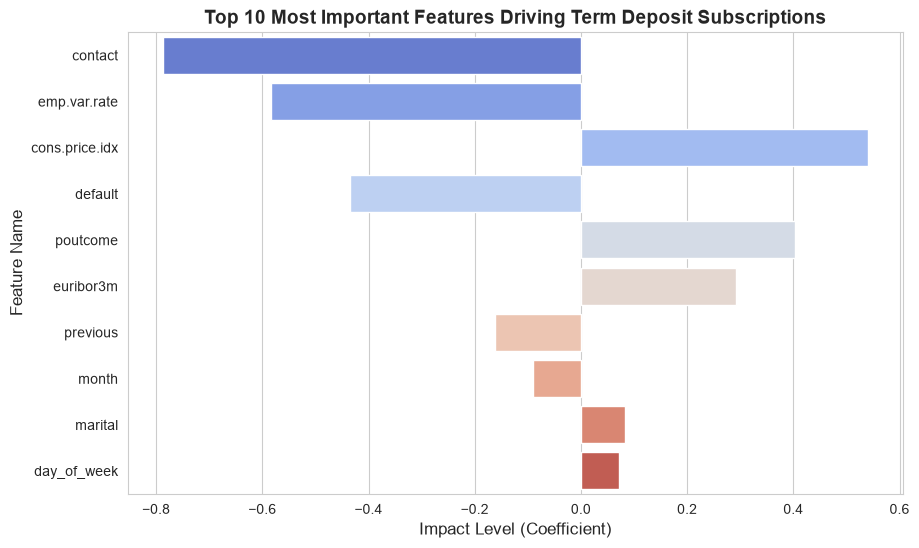

Business Insight: The feature importance chart reveals which customer traits have the biggest impact on the model's decision. Features with high positive or negative coefficients are the key indicators for a successful marketing campaign.


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Muting all warnings for a clean look
warnings.filterwarnings('ignore')

# Extract feature importance (coefficients) from the trained Logistic Regression model
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.coef_[0]})

# Sort features by absolute importance to see the most impactful ones
feature_importance['Absolute_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Absolute_Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
# Added 'hue' and 'legend=False' to fix the Seaborn FutureWarning
sns.barplot(data=feature_importance, x='Importance', y='Feature', hue='Feature', palette='coolwarm', legend=False)

plt.title('Top 10 Most Important Features Driving Term Deposit Subscriptions', fontsize=14, fontweight='bold')
plt.xlabel('Impact Level (Coefficient)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.show()

print("Business Insight: The feature importance chart reveals which customer traits have the biggest impact on the model's decision. Features with high positive or negative coefficients are the key indicators for a successful marketing campaign.")

## Key Takeaways (Executive Summary)

* **Target Demographics:** The 30-40 age group and working professionals (admin, blue-collar, and technicians) show the highest engagement and should be the primary focus of marketing efforts.
* **Engagement Matters:** Call duration is a critical factor; successful conversions ('yes') have an average call duration of ~553 seconds, which is more than double the duration of unsuccessful calls.
* **Optimal Contact Method:** Reaching out to customers via cellular networks is significantly more effective than traditional telephone lines.
* **Campaign Strategy:** The probability of a successful subscription is highest within the first 1 to 3 contacts. Persistently calling beyond 3 times drastically reduces the conversion rate.
* **Predictive Power:** The logistic regression model demonstrates that combining employment metrics (like EURIBOR 3m) with campaign data can accurately predict a customer's likelihood to subscribe.